In [1]:
from elos.elo_tracker import EloTracker
from utils.misc_utils import load_all_games_csv, get_teams
from utils.math_utils import predict_lr, p, w
from simulation.simulation import MLBSimulator
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score

# Simulation

This notebook focuses on simulating a given season via Elo ratings ratings, estimating each team's probability of making it to the playoffs and different rounds within them.

It then calculates the r^2 between actual and predicted wins for the season.

In [2]:
season = 2025

## Get Divisions and Leagues for Teams

In [3]:
# Get divisions and leagues for each team
AL_EAST = {'TOR', 'NYA', 'BOS', 'TBA', 'BAL'}
AL_CENTRAL = {'CLE', 'DET', 'KCA', 'MIN', 'CHA'}
AL_WEST = {'SEA', 'HOU', 'TEX', 'ATH', 'ANA'}

AL = [AL_EAST, AL_CENTRAL, AL_WEST]

NL_EAST = {'PHI', 'NYN', 'MIA', 'ATL', 'WAS'}
NL_CENTRAL = {'MIL', 'CHN', 'CIN', 'SLN', 'PIT'}
NL_WEST = {'LAN', 'SDN', 'SFN', 'ARI', 'COL'}

NL = NL_EAST, NL_CENTRAL, NL_WEST

TEAMS = AL_EAST | AL_CENTRAL | AL_WEST | NL_EAST | NL_CENTRAL | NL_WEST
TEAMS

{'ANA',
 'ARI',
 'ATH',
 'ATL',
 'BAL',
 'BOS',
 'CHA',
 'CHN',
 'CIN',
 'CLE',
 'COL',
 'DET',
 'HOU',
 'KCA',
 'LAN',
 'MIA',
 'MIL',
 'MIN',
 'NYA',
 'NYN',
 'PHI',
 'PIT',
 'SDN',
 'SEA',
 'SFN',
 'SLN',
 'TBA',
 'TEX',
 'TOR',
 'WAS'}

## Get Elo Ratings for each team

In [4]:
all_games = load_all_games_csv('../data/gameinfo_cleaned.csv', preprocess=True)
games_before = all_games[all_games['season'] < season] # Up to season

teams = get_teams(games_before)
et = EloTracker()

et.add_history(games_before)

# Get dict of latest elos for teams
#elos_map = {team: et.elos_map[team][0] for team in TEAMS}
elos_map = {team: et.elos_map[team][0] for team in (TEAMS | {'OAK'}) - {'ATH'}}
elos_map['ATH'] = et.elos_map['OAK'][0]

# Revert to mean by 1/3 for new season
elos_map = {team: elos_map[team] + (1500 - elos_map[team]) / 3 for team in TEAMS}

elos_map

/Users/lancehendricks/Documents/College Coding/ML/Elo Ratings/analysis/src/utils/misc_utils.py:29: DtypeWarning: Columns (10,11,13,17,19,20,21,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  all_games = pd.read_csv(filename)


{'COL': 1462.099952940796,
 'BOS': 1498.0906207045605,
 'MIA': 1474.8425358668817,
 'NYA': 1521.865698858941,
 'CHA': 1432.28608563123,
 'ATL': 1522.6776363652439,
 'CLE': 1510.3684505749704,
 'LAN': 1543.4531570264198,
 'SLN': 1501.475780378102,
 'CIN': 1491.346298436719,
 'TBA': 1509.6581249129413,
 'KCA': 1491.9308675960867,
 'SDN': 1523.9338488249748,
 'MIL': 1520.8962222440791,
 'BAL': 1517.1047622196943,
 'TOR': 1495.5159210103802,
 'PHI': 1522.731826710146,
 'MIN': 1498.029487442219,
 'NYN': 1516.1993638221697,
 'DET': 1505.9052275046763,
 'HOU': 1520.0027065050556,
 'SEA': 1510.3629520246325,
 'PIT': 1486.1727607963771,
 'ANA': 1464.2556058241114,
 'WAS': 1476.3742822615345,
 'TEX': 1498.5358956818375,
 'ARI': 1514.5682422324635,
 'SFN': 1498.8203286993905,
 'CHN': 1502.8983221771189,
 'ATH': 1467.6783484973278}

## Get Schedule
Assume the filename is f'../data/{season}schedule_clean.csv'

In [5]:
schedule_df = all_games[(all_games['season'] == season) & (all_games['gametype'] == 'regular')]

pd.read_csv(f'../data/{season}schedule_clean.csv')
schedule_df.head()

,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,usedh,...,vispitcherminusteamrgs,homefirstpitchergameofseason,visfirstpitchergameofseason,homelastkwinpct,vislastkwinpct,adjustedvisrestdays,adjustedhomerestdays,adjustedhomedistancetraveled,adjustedvisdistancetraveled,adjustedmarginofvictory
gid,,,,,,,,,,,,,,,,,,,,,
CHN202503180,LAN,CHN,TOK01,20250318,0.0,7:10PM,night,9.0,2.0,True,...,3.894620,True,True,NaN,NaN,3.0,3.0,0.0,17.623476,1.732051
CHN202503190,LAN,CHN,TOK01,20250319,0.0,7:10PM,night,9.0,2.0,True,...,-23.900000,True,True,0.0,1.0,1.0,1.0,0.0,0.000000,1.732051
ARI202503270,CHN,ARI,PHO01,20250327,0.0,7:10PM,night,9.0,2.0,True,...,-12.000000,True,False,NaN,0.0,3.0,3.0,0.0,17.947542,2.000000
CHA202503270,ANA,CHA,CHI12,20250327,0.0,3:10PM,day,9.0,2.0,True,...,4.239583,True,True,NaN,NaN,3.0,3.0,0.0,12.007542,2.645751
CIN202503270,SFN,CIN,CIN09,20250327,0.0,4:10PM,day,9.0,2.0,True,...,2.735129,True,True,NaN,NaN,3.0,3.0,0.0,12.677129,1.414214


## Simulate Seasons

In [6]:
def predict_lr_use_pitchers_if_first_games(home_elo: float, away_elo: float, game: pd.Series):
    """Uses logistic regression with pitcher rating included if it is each pitcher's first game, and
    the game is not None.
    
    We allow the game to be None in case it is a playoff game and we don't have explicit information for it.
    In this case, we just use home advantage.
    
    Args:
        home_elo (float): Elo of home team.
        away_elo (float): Elo of away team.
        game (pd.Series): Row of game dataframe containing game info including rest days, travel, etc. If none,
            this will default the calculation to adjust for home advantage only.
    
    """
    
    if game is None: # For playoffs we don't have rows in the dataframe
        elo_diff = away_elo - home_elo
    
        home_adv_diff = 0 - 1
    
        x = np.array([elo_diff, home_adv_diff])
        return p(x.T, w[:2]).item()
    
    else:
        game = game.copy()
        
        if not (game['homefirstpitchergameofseason'] and game['homefirstpitchergameofseason']):
            game['homepitcherminusteamrgs'] = 0
            game['vispitcherminusteamrgs'] = 0
            
        return predict_lr(home_elo, away_elo, game)

In [7]:
sim = MLBSimulator(schedule_df, AL, NL, elos_map)
sim.simulate_seasons(1000)
team_results = sim.team_results

100%|██████████| 1000/1000 [01:11<00:00, 14.00it/s]


In [8]:
# Get DF of results
avg_wins = [team_results[team][0] for team in TEAMS]
playoff_pcts = [team_results[team][1] for team in TEAMS]
div_pcts = [team_results[team][2] for team in TEAMS]
champ_pcts = [team_results[team][3] for team in TEAMS]
ws_pcts = [team_results[team][4] for team in TEAMS]
winner_pcts = [team_results[team][5] for team in TEAMS]

# Make PD dataframe to easily visualize
results_df = pd.DataFrame({'Team':list(TEAMS), 'Avg. Wins':avg_wins, 'Playoff %':playoff_pcts,
                           'Divisional %':div_pcts, 'Championship %':champ_pcts, 'WS %':ws_pcts, 'Win WS %':winner_pcts})
results_df = results_df.sort_values(by='Win WS %', ascending=False).reset_index(drop=True)
results_df

,Team,Avg. Wins,Playoff %,Divisional %,Championship %,WS %,Win WS %
0,LAN,91.214,79.3,60.3,34.2,19.6,11.8
1,PHI,86.880,61.2,43.3,22.2,11.2,6.5
2,HOU,87.337,69.5,50.0,27.7,13.9,6.0
3,ATL,85.802,58.6,41.8,21.1,11.1,5.9
4,MIL,86.337,61.6,44.3,21.8,11.2,5.6
5,NYA,86.188,61.2,45.0,23.5,12.6,5.4
6,BAL,85.308,58.2,39.0,21.5,11.6,5.3
7,NYN,84.247,49.9,34.5,18.8,8.3,5.0
8,SDN,86.192,58.0,40.2,20.8,10.7,4.9
9,ARI,83.257,48.7,28.7,14.5,7.9,4.6


## Compare With Actual Data

In [9]:
actual_team_wins_map = {team: 0 for team in TEAMS}

for _, row in schedule_df.iterrows():
    home = row['hometeam']
    away = row['visteam']
    home_won = row['homewon']
    actual_team_wins_map[home] += home_won
    actual_team_wins_map[away] += 1 - home_won
    
actual_team_wins = [actual_team_wins_map[team] for team in TEAMS]


### Plot actual vs predicted



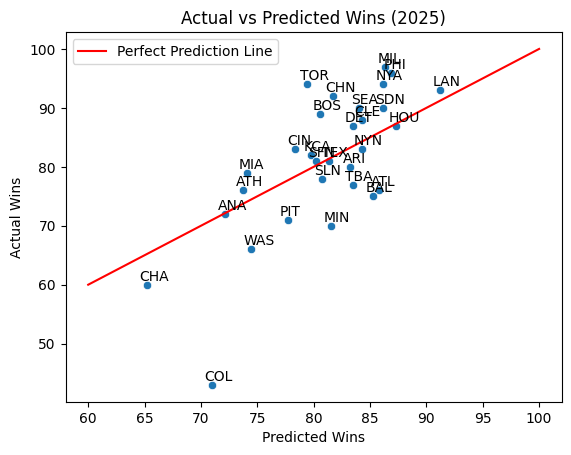

In [10]:
avg_wins_np = np.array(avg_wins)
actual_wins_np = np.array(actual_team_wins)

sns.scatterplot(x=avg_wins_np, y=actual_wins_np)
plt.xlabel('Predicted Wins')
plt.ylabel('Actual Wins')
plt.title(f'Actual vs Predicted Wins ({season})')

# Label points
for i, team in enumerate(TEAMS):
    plt.text(x=avg_wins_np[i] - 0.7, y=actual_wins_np[i] + 0.7, s=team)
    
# Line with slope 1 (perfect)
xp = np.linspace(60,100)
yp = xp
plt.plot(xp, yp, color='red', label='Perfect Prediction Line')

plt.legend()

### r^2 Score

In [11]:
r2_score(actual_wins_np, avg_wins_np)

0.4690468341733871

.493 with pitcher and other stuff, margin of victory
.480 with pitcher and other stuff, no margin of victory
.468 with just home adv, no margin of victory

### r^2 Score Baseline: FanGraphs

In [14]:
fangraphs_team_wins_map = {
    'LAN': 96,   # Dodgers
    'ATL': 93,   # Braves
    'PHI': 87,   # Phillies
    'NYN': 86,   # Mets
    'ARI': 86,   # Diamondbacks
    'NYA': 86,   # Yankees
    'BOS': 85,   # Red Sox
    'TEX': 84,   # Rangers
    'SEA': 84,   # Mariners
    'CHN': 84,   # Cubs
    'HOU': 84,   # Astros
    'BAL': 83,   # Orioles
    'MIN': 83,   # Twins
    'TOR': 83,   # Blue Jays
    'SDN': 82,   # Padres
    'DET': 82,   # Tigers
    'TBA': 82,   # Rays
    'SFN': 81,   # Giants
    'MIL': 81,   # Brewers
    'KCA': 81,   # Royals
    'SLN': 79,   # Cardinals
    'PIT': 78,   # Pirates
    'CIN': 78,   # Reds
    'CLE': 78,   # Guardians
    'ATH': 76,   # Athletics
    'ANA': 76,   # Angels
    'WAS': 73,   # Nationals
    'MIA': 71,   # Marlins
    'COL': 65,   # Rockies
    'CHA': 63    # White Sox
}



fangraphs_wins_np = np.array([fangraphs_team_wins_map[team] for team in TEAMS])

In [ ]:
r2_score(actual_wins_np, fangraphs_wins_np)

0.44976306470810024